# cufsm-rs-py quickstart

Finite strip buckling of thin-walled sections (CUFSM) from Python. The engine is
[cufsm-rs](https://github.com/mageaustralia/cufsm-rs), the Rust port of CUFSM that runs CivilKit
Buckling in the browser; this package makes the same engine available here.

**Units.** The package is unit-agnostic, as CUFSM is: use any consistent set. The tutorial C
below is in inches and ksi (CUFSM's own example); the lipped C is in mm and MPa.

**Load factors** multiply the model's reference stresses. With reference stresses from the
squash load `Py`, a load factor reads as `Pcr / Py`.

In [1]:
import numpy as np
import cufsm_rs as fsm
from cufsm_rs.plot import plot_section, plot_signature, plot_mode
fsm.__version__

'0.1.0'

## The CUFSM tutorial C (inches, ksi)

A model is CUFSM's arrays: `prop` `[mat#, Ex, Ey, vx, vy, G]`, `node`
`[node#, x, z, xdof, zdof, ydof, qdof, stress]`, `elem` `[elem#, nodei, nodej, t, mat#]`.

In [2]:
xz = [(5, 1), (5, 0), (2.5, 0), (0, 0), (0, 3), (0, 6), (0, 9), (2.5, 9), (5, 9), (5, 8)]
tut = fsm.Model(
    prop=[[100, 29500, 29500, 0.3, 0.3, 11346.15]],
    node=[[i + 1, x, z, 1, 1, 1, 1, 0] for i, (x, z) in enumerate(xz)],
    elem=[[i + 1, i + 1, i + 2, 0.1, 100] for i in range(9)],
)
tut

node#,x,z,xdof,zdof,ydof,qdof,stress
1,5,1,1,1,1,1,0
2,5,0,1,1,1,1,0
3,2.5,0,1,1,1,1,0
4,0,0,1,1,1,1,0
5,0,3,1,1,1,1,0
6,0,6,1,1,1,1,0
7,0,9,1,1,1,1,0
8,2.5,9,1,1,1,1,0
9,5,9,1,1,1,1,0
10,5,8,1,1,1,1,0


In [3]:
fsm.section_properties(tut)

,value,
A,2.1,area
xcg,1.66667,centroid x
zcg,4.5,centroid z
Ixx,29.5425,second moment about x
Izz,7.50092,second moment about z
Ixz,0,product moment
thetap,0,principal axis angle (deg)
I11,29.5425,major principal second moment
I22,7.50092,minor principal second moment
J,0.007,St Venant torsion constant


In [4]:
y = fsm.first_yield(tut, fy=50)   # extreme fibre (element faces), as current CUFSM
y

,value
fy,50
Py,105
Mxx,324.643
Mzz,110.851
M11,324.643
M22,110.851
B,328.386


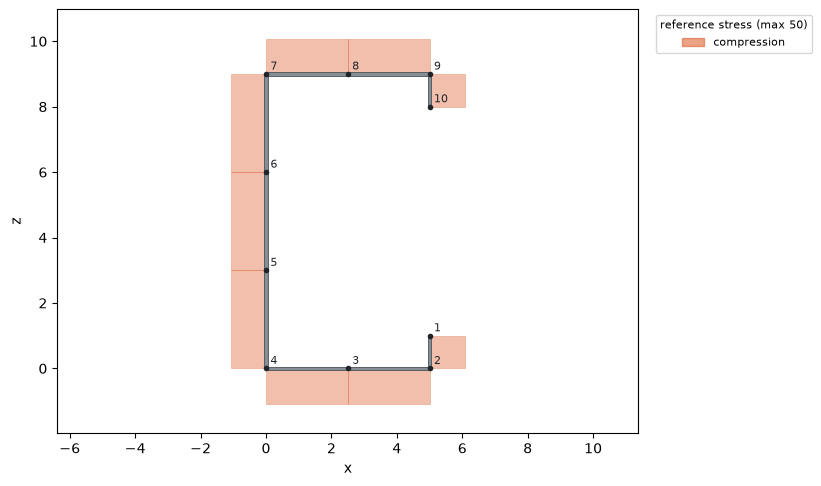

In [5]:
tut_c = fsm.stress(tut, P=y.Py)   # reference stress: the squash load
plot_section(tut_c, node_numbers=True);

In [6]:
sig = fsm.signature(tut_c, np.logspace(0, 3, 80))
sig

minimum,length,load factor
1,7.26981,0.353246
2,43.8733,0.544105


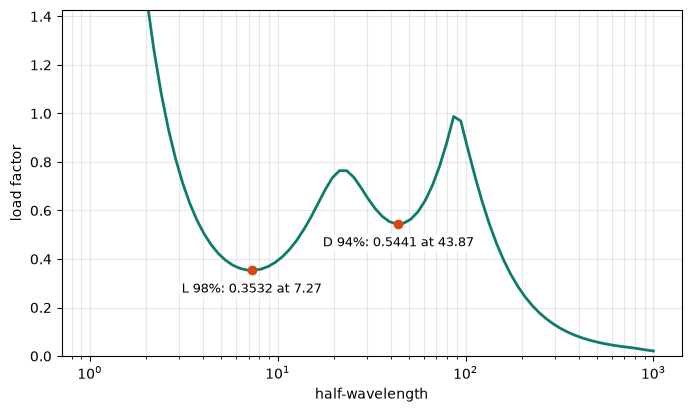

In [7]:
plot_signature(sig, classify=True);

In [8]:
# G, D, L, O percentages of the lowest mode at each minimum
dict(zip(["first", "second"], np.round(sig.classify_minima(), 1).tolist()))

{'first': [0.3, 1.5, 98.1, 0.2], 'second': [1.3, 94.1, 4.6, 0.1]}

## Mode shapes

`mode_shape(i_length, k_mode)` splits a mode into per-node arrays `u`, `v`, `w`, `theta`, each
of shape `(terms, nodes)`; the raw vector in CUFSM's DOF order stays on `.dofs`.

7.471670675868078 0.3535374502347406 (1, 10)


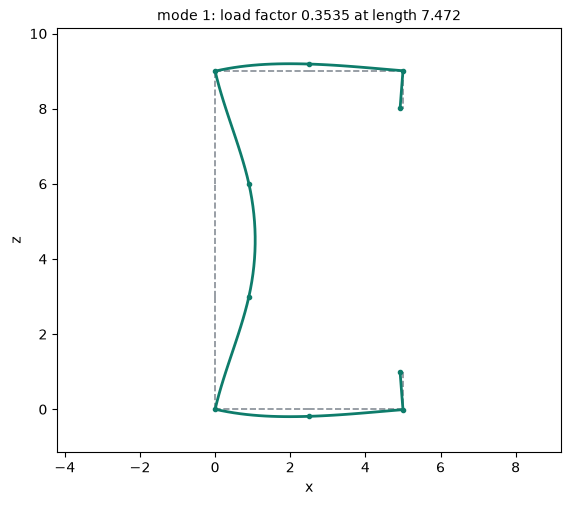

In [9]:
i = int(np.argmin(np.abs(sig.lengths - sig.minima[0, 0])))   # the length nearest the first minimum
ms = sig.mode_shape(i)
print(ms.length, ms.load_factor, ms.u.shape)
plot_mode(sig, i);

## A 200 x 76 x 15 x 1.9 mm lipped C (mm, MPa)

In [10]:
lc = fsm.lipped_c(200, 76, 15, 1.9, ri=3)   # outside dimensions, inside radius; E = 203000 MPa
p = fsm.section_properties(lc)
yl = fsm.first_yield(lc, 450)
print(f"A = {p.A:.1f} mm2, Ixx = {p.Ixx:.4g} mm4, Py = {yl.Py / 1e3:.1f} kN, Mxx = {yl.Mxx / 1e6:.2f} kNm")
lc_c = fsm.stress(lc, P=yl.Py)
sig_lc = fsm.signature(lc_c, np.logspace(1, 4, 90))
sig_lc

A = 697.3 mm2, Ixx = 4.306e+06 mm4, Py = 313.8 kN, Mxx = 19.38 kNm


minimum,length,load factor
1,153.738,0.211391
2,519.802,0.32907


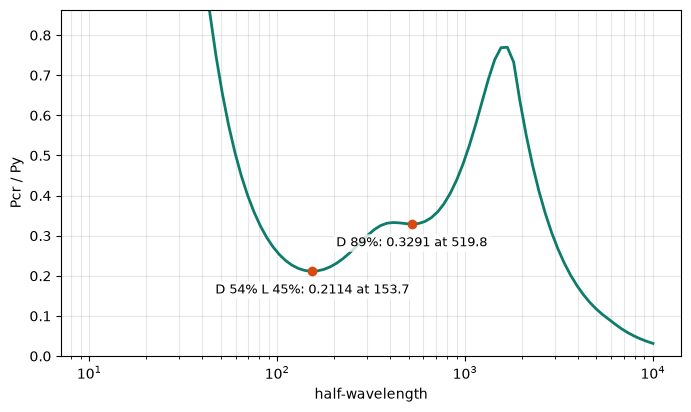

In [11]:
ax = plot_signature(sig_lc, classify=True)
ax.set_ylabel("Pcr / Py");

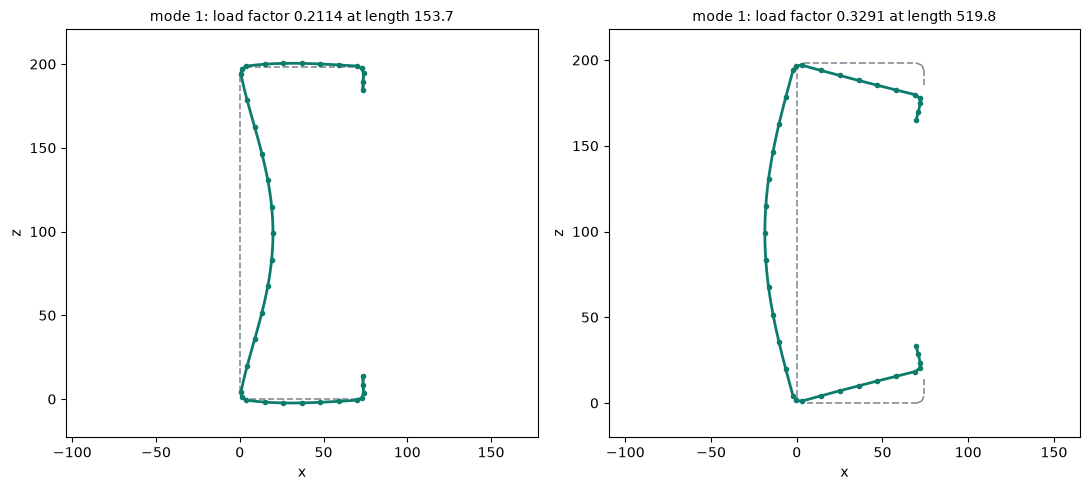

In [12]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
for ax, (L, _) in zip(axs, sig_lc.minima):
    plot_mode(fsm.strip(lc_c, [L], neigs=1), 0, ax=ax)
fig.tight_layout()

In [13]:
# Pure distortional buckling (cFSM, restricted to the D space) at the second minimum
fsm.strip(lc_c, [sig_lc.minima[1, 0]], spaces="D", neigs=1).load_factors

array([[0.37245973]])

## General end conditions

With end conditions other than S-S, lengths are physical member lengths and each length needs
several longitudinal terms (`m_all`). The terms must reach the short half-waves too: here, for
clamped-clamped (C-C) ends, terms 1 to 3 for global buckling plus the terms near `L / Lcr` for
each signature minimum (a list of term lists, one per length).

In [14]:
L = np.array([500.0, 1000.0, 2000.0, 3000.0, 4000.0])
m_all = []
for Li in L:
    near = {m for Lcr in sig_lc.minima[:, 0] for m in range(round(Li / Lcr) - 2, round(Li / Lcr) + 3) if m > 0}
    m_all.append(sorted({1, 2, 3} | near))
cc = fsm.strip(lc_c, L, m_all=m_all, bc="C-C", neigs=3)
cc

length,lowest load factor
500,0.230374
1000,0.216616
2000,0.212816
3000,0.212099
4000,0.211753


In [15]:
gdlo = cc.classify()[:, 0, :]   # lowest mode at each length
for Li, lf, c in zip(L, cc.curve, gdlo):
    print(f"L = {Li:6.0f} mm: Pcr/Py = {lf:.3f}, " + " ".join(f"{n} {v:.0f}%" for n, v in zip(fsm.MODE_CLASSES, c)))

L =    500 mm: Pcr/Py = 0.230, G 1% D 54% L 45% O 0%
L =   1000 mm: Pcr/Py = 0.217, G 1% D 54% L 45% O 0%
L =   2000 mm: Pcr/Py = 0.213, G 1% D 54% L 45% O 0%
L =   3000 mm: Pcr/Py = 0.212, G 1% D 54% L 45% O 0%
L =   4000 mm: Pcr/Py = 0.212, G 1% D 54% L 45% O 0%


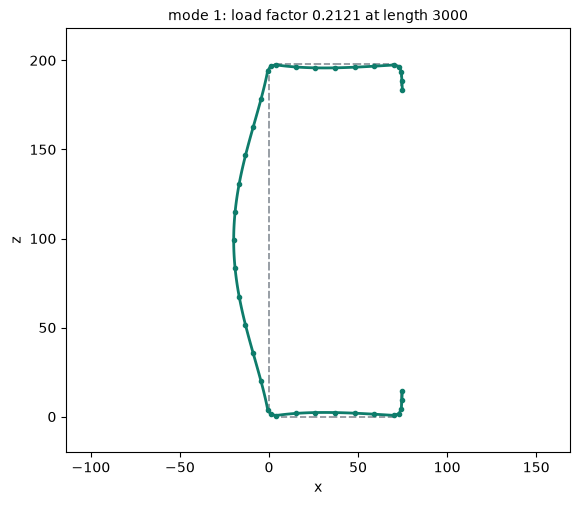

In [16]:
plot_mode(cc, 3);